# TensorFlow Basics

TensorFlow uses **Keras** API as an interface for developing Machine Learning Applications. Keras covers every step of the machine learning workflow, from data processing to hyperparameter tuning to deployment. It was developed with a focus on enabling fast experimentation.


### Keras Core Components

**Layers**: simple input/output transformation. Encapsulates a state (weights) and a computaion method.

**Models**: A directed graph of layers. It's an object that groups layers and that can be trained on data. 

`Sequential`: the simplest model. Linear stack of layers.

`Model` Class: `tf.keras.Model`:has built-in methods for training and testing.

- `tf.keras.Model.fit`: trains the model (with a fixed number of epochs)
- `tf.keras.Model.predict`: inference from samples
- `tf.keras.Model.evaluate`: returns loss and metrics
- `tf.keras.Model.compile`: sets the loss and evaluation method.


### Creating a simple Sequential model

It is appropiate for a _plain stick of layers_ where each layer has **exactly** one input tensor and one output tensor


In [7]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers

# Define Sequential model with 3 layers 
# Dense is a Fully Connected Layer with N neurons and activation function.
model = keras.Sequential(
    [
        layers.Dense(2, activation="relu", name="layer1"),
        layers.Dense(3, activation="relu", name="layer2"),
        layers.Dense(4, name="layer3")
    ]
)

# call model on a test input
x = tf.ones((3,3))
y = model(x)



2025-04-04 09:52:17.144965: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-04-04 09:52:17.145415: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-04-04 09:52:17.145476: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1743771137.145796 1433868 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1743771137.146326 1433868 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning

In [5]:
from keras import layers

# Define Sequential model with 3 layers 
# Dense is a Fully Connected Layer with N neurons and activation function.
model = tf.keras.Sequential(
    [
        layers.Dense(2, activation="relu", name="layer1"),
        layers.Dense(3, activation="relu", name="layer2"),
        layers.Dense(4, name="layer3")
    ]
)

# call model on a test input
x = tf.ones((3,3))
y = model(x)

print(y)

tf.Tensor(
[[-0.06004147  0.16744421  0.122429   -0.03715298]
 [-0.06004147  0.16744421  0.122429   -0.03715298]
 [-0.06004147  0.16744421  0.122429   -0.03715298]], shape=(3, 4), dtype=float32)


You can load datasets directly from `tensorflow.keras`.
The following code loadas the `fashion_mnist` dataset with the method `load_data()`. Then the images are normalized.

#### Fashion MNIST: classes

| Label | Class |  
|-----------|-----------|
|0  | T-shirt/top	   |
|1	|Trouser    |
|2	|Pullover|
|3	|Dress|
|4	|Coat|
|5	|Sandal|
|6	|Shirt|
|7	|Sneaker|
|8	|Bag	|
|9	|Ankle boot|

In [1]:
## Datasets
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import fashion_mnist

# Fashion MNIST
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train_norm, x_test_norm = x_train / 255.0, x_test / 255.0  

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

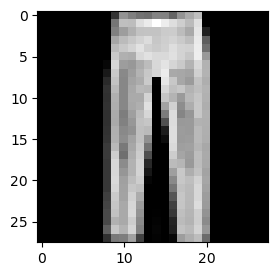

In [3]:
import matplotlib.pyplot as plt
# Image index

N = 16

plt.figure(figsize=(3,3))
plt.imshow(x_train[N], cmap='gray')


# Labels
y_train

## Simple Architecture

- the input size is = [28,28]
- the output siez is 10.

The architecture is declared with Sequential([]). 

The input image is flattened and turn into a tensor [28*28,1].

There are 4 layers of 256, 64, 32 and 10 neurons. In the first layer, 20% of the weights are dropped using `Dropout(0.2)`.


In [8]:
# MLP architecture

w = 28
h = 28
n_classes = 10

model= keras.Sequential([

    layers.Flatten(input_shape=(w, h)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(n_classes, activation='softmax')

])


/Users/denisegayet/env_tf/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Compiling the model

`compile()` is a method from keras to caractherize the model. It needs a loss function, an optimizer, and a metric. The ones used here are `sparse_categorical_crossentropy`, Stochastic Gradient Descent (with a 0.001 learning rate) and `accuracy`. 

In [9]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam

lr = 0.001
# op = Adam(lr)
op = SGD(lr)

model.compile(loss='sparse_categorical_crossentropy', optimizer=op, metrics=['accuracy'])

## Summary

To get a summary of the model, the method `summary()` is used.

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,818 (858.66 KB)

 Trainable params: 219,818 (858.66 KB)

 Non-trainable params: 0 (0.00 B)

## Training

With the `fit()` method, the model gets trained using the training dataset. Validation sets can be set.

Arguments: `epochs`, `batch_size`, `validation_split`.

In [11]:
history = model.fit(x_train_norm, y_train, epochs= 32, batch_size = 50, validation_split=0.2)

Epoch 1/32


2025-04-04 10:01:18.254827: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


960/960 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2151 - loss: 2.1909 - val_accuracy: 0.6009 - val_loss: 1.4025
Epoch 2/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5543 - loss: 1.3721 - val_accuracy: 0.6802 - val_loss: 1.0163
Epoch 3/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6358 - loss: 1.0565 - val_accuracy: 0.7078 - val_loss: 0.8586
Epoch 4/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6733 - loss: 0.9198 - val_accuracy: 0.7329 - val_loss: 0.7754
Epoch 5/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7002 - loss: 0.8385 - val_accuracy: 0.7491 - val_loss: 0.7221
Epoch 6/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7219 - loss: 0.7868 - val_accuracy: 0.7623 - val_loss: 0.6847
Epoch 7/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7312 - loss: 0.7526 - val_accuracy: 0.7736 - val_loss: 0.6557
Epoch 8/32
960/960 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7469 - loss: 0.7196 - val_accuracy: 0.7816 - val

In [12]:
# Model evaluation
test_loss, test_acc = model.evaluate(x_test_norm, y_test)
print(f"\nTest accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8181 - loss: 0.5114

Test accuracy: 0.8128


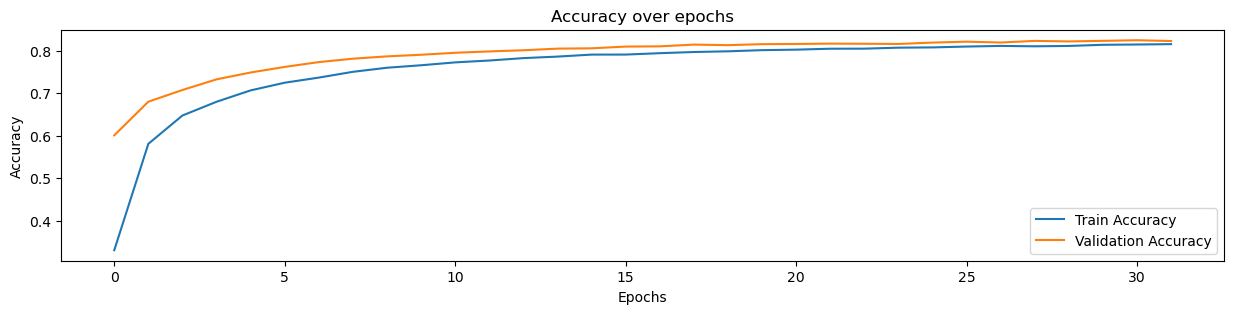

In [13]:
# Plot accuracy over epochs
plt.figure(figsize=(15,3))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over epochs')
plt.show()

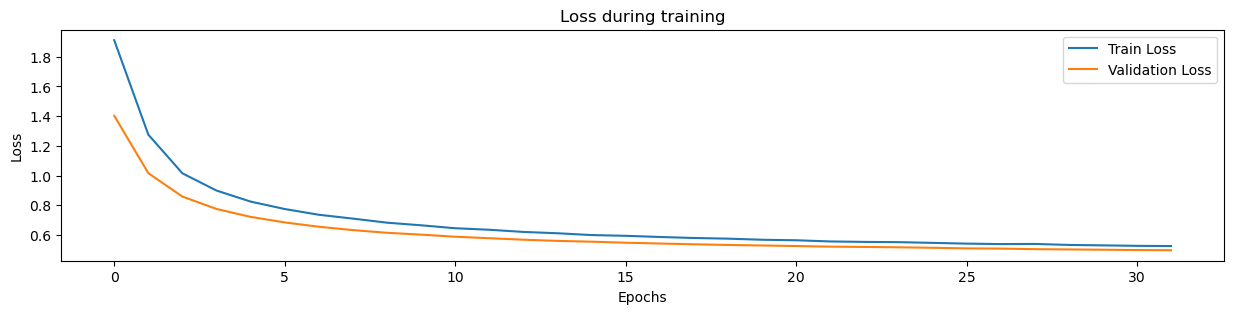

In [14]:
# Plot accuracy over loss
plt.figure(figsize=(15,3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 10)
Predicted Class: 1 - True label: 1


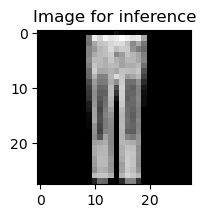

In [22]:
index = 15

plt.figure(figsize=(2,2))
plt.imshow(x_test[index], cmap='gray')
plt.title("Image for inference")

# x_test_norm_reshaped = x_test[index].reshape(-1, 28*28)

y_pred = model.predict(x_test_norm)

print(y_pred.shape)

y_pred = np.argmax(y_pred, axis=1) 
print(f"Predicted Class: {y_pred[index]} - True label: {y_test[index]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


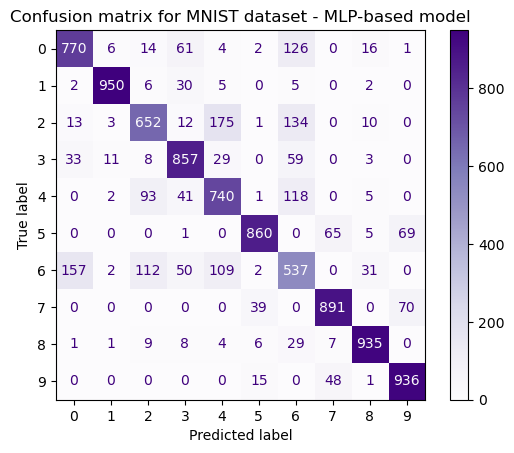

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score


y_pred_probs = model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Purples')
plt.title('Confusion matrix for MNIST dataset - MLP-based model')
plt.show()

In [ ]:
# saving the model

model.save("fashionMNIST.h5")